In [4]:
import json

kaggle_dict = {
    "username": "Sathya Mozhi",
    "key": "KGAT_ce2016f704f725fd31c0c84a8c8eb048"
}

with open("kaggle.json", "w") as file:
    json.dump(kaggle_dict, file)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download climate dataset
!kaggle datasets download -d berkeleyearth/climate-change-earth-surface-temperature-data

!unzip climate-change-earth-surface-temperature-data.zip

Dataset URL: https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data
License(s): CC-BY-NC-SA-4.0
  0% 0.00/84.7M [00:00<?, ?B/s]
100% 84.7M/84.7M [00:00<00:00, 1.37GB/s]
Archive:  climate-change-earth-surface-temperature-data.zip
  inflating: GlobalLandTemperaturesByCity.csv  
  inflating: GlobalLandTemperaturesByCountry.csv  
  inflating: GlobalLandTemperaturesByMajorCity.csv  
  inflating: GlobalLandTemperaturesByState.csv  
  inflating: GlobalTemperatures.csv  


In [5]:
import pandas as pd

df = pd.read_csv("GlobalLandTemperaturesByCountry.csv")

df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [6]:
df = df[['AverageTemperature', 'Country']]

df = df.dropna()

# Reduce size to avoid RAM issue
df = df.sample(50000, random_state=42)

df.head()

,AverageTemperature,Country
500353,26.420,Suriname
548987,15.614,United Kingdom (Europe)
189222,26.331,French Guiana
372731,9.445,New Zealand
489364,21.550,South Korea


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use only numerical column
X = df[['AverageTemperature']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,AverageTemperature,Country,Cluster
500353,26.420,Suriname,0
548987,15.614,United Kingdom (Europe),2
189222,26.331,French Guiana,0
372731,9.445,New Zealand,2
489364,21.550,South Korea,0


In [8]:
# New temperature input (example)
new_data = pd.DataFrame({
    'AverageTemperature': [30]   # You can change this value
})

# Scale new input (IMPORTANT!)
new_data_scaled = scaler.transform(new_data)

# Predict cluster
cluster_prediction = kmeans.predict(new_data_scaled)

print("Predicted Cluster:", cluster_prediction[0])

Predicted Cluster: 0


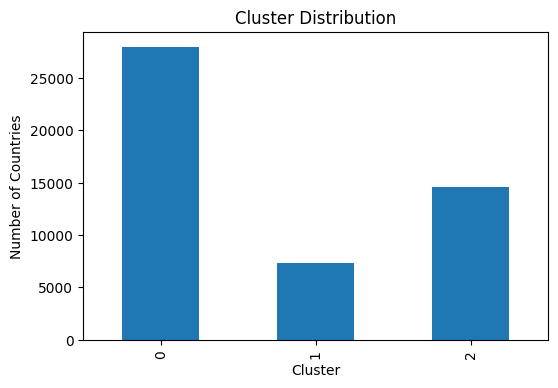

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Countries")
plt.show()

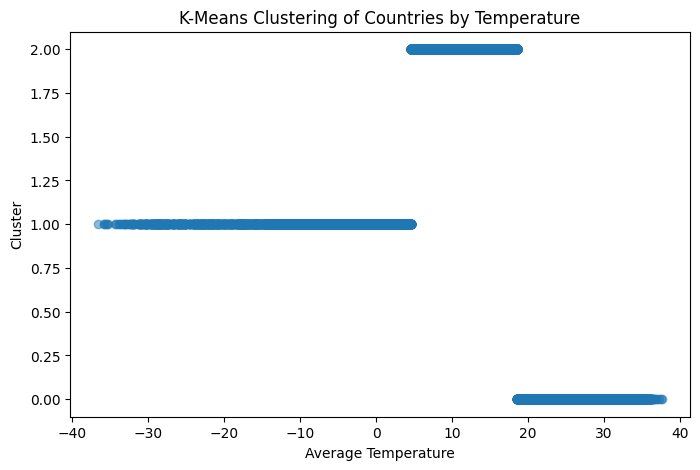

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df['AverageTemperature'], df['Cluster'], alpha=0.5)

plt.title("K-Means Clustering of Countries by Temperature")
plt.xlabel("Average Temperature")
plt.ylabel("Cluster")
plt.show()

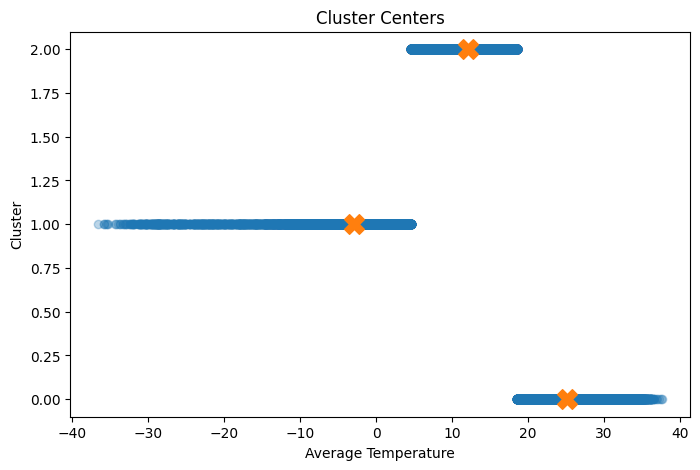

Cluster Centers (Actual Temperature Values):
[[25.1603272 ]
 [-2.88289799]
 [12.0487078 ]]


In [11]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,5))

plt.scatter(df['AverageTemperature'], df['Cluster'], alpha=0.3)
plt.scatter(centers, [0,1,2], marker='X', s=200)

plt.title("Cluster Centers")
plt.xlabel("Average Temperature")
plt.ylabel("Cluster")
plt.show()

print("Cluster Centers (Actual Temperature Values):")
print(centers)